#  AutoML avec PyCaret – Prédiction de Souscription

In [1]:

#  Imports
import pandas as pd
from pycaret.classification import *

#  Chargement des données
df = pd.read_csv("bank_small_clean.csv")

#  Vérification initiale
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11092 entries, 0 to 11091
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        11092 non-null  int64 
 1   job                        11092 non-null  object
 2   marital_status             11092 non-null  object
 3   education_level            11092 non-null  object
 4   credit_default             11092 non-null  object
 5   annual_balance             11092 non-null  int64 
 6   housing_loan               11092 non-null  object
 7   personal_loan              11092 non-null  object
 8   contact_type               11092 non-null  object
 9   contact_day                11092 non-null  int64 
 10  contact_month              11092 non-null  object
 11  current_campaign_contacts  11092 non-null  int64 
 12  last_contact               11092 non-null  int64 
 13  previous_campaign_contact  11092 non-null  int64 
 14  previo

,age,job,marital_status,education_level,credit_default,annual_balance,housing_loan,personal_loan,contact_type,contact_day,contact_month,current_campaign_contacts,last_contact,previous_campaign_contact,previous_campaign_outcome,deposit,contact_status
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,1,-1,0,unknown,yes,no_contact
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,2,-1,0,unknown,yes,no_contact


In [3]:
#  Suppression de colonnes non utiles (facultatif mais conseillé ici)
cols_to_drop = ['contact_day', 'contact_month']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)


In [7]:

#  Initialisation PyCaret
clf = setup(
    data=df,
    target='deposit',
    session_id=42,
    normalize=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    categorical_features=['job', 'marital_status', 'education_level', 'credit_default',
                          'housing_loan', 'personal_loan', 'contact_type', 'previous_campaign_outcome', 'contact_status'],
    use_gpu=False,
    verbose=True
)


,Description,Value
0,Session id,42
1,Target,deposit
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(11092, 15)"
5,Transformed data shape,"(11092, 34)"
6,Transformed train set shape,"(7764, 34)"
7,Transformed test set shape,"(3328, 34)"
8,Numeric features,5
9,Categorical features,9


In [9]:

#  Comparaison automatique des modèles
best_model = compare_models()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.6983,0.7602,0.6983,0.7008,0.6952,0.3901,0.3950,0.9610
ada,Ada Boost Classifier,0.6974,0.7548,0.6974,0.6991,0.6949,0.3889,0.3927,0.5130
lightgbm,Light Gradient Boosting Machine,0.6944,0.7492,0.6944,0.6967,0.6912,0.3820,0.3868,1.1920
lr,Logistic Regression,0.6835,0.7409,0.6835,0.6842,0.6813,0.3613,0.3640,1.5590
ridge,Ridge Classifier,0.6815,0.7402,0.6815,0.6823,0.6790,0.3569,0.3599,0.2420
lda,Linear Discriminant Analysis,0.6815,0.7402,0.6815,0.6823,0.6790,0.3569,0.3599,0.2650
rf,Random Forest Classifier,0.6790,0.7309,0.6790,0.6793,0.6772,0.3527,0.3548,0.9730
nb,Naive Bayes,0.6538,0.7170,0.6538,0.6583,0.6466,0.2970,0.3057,0.2570
knn,K Neighbors Classifier,0.6519,0.6888,0.6519,0.6514,0.6506,0.2990,0.2999,1.0510
svm,SVM - Linear Kernel,0.6519,0.7027,0.6519,0.6519,0.6504,0.2995,0.3007,0.2920


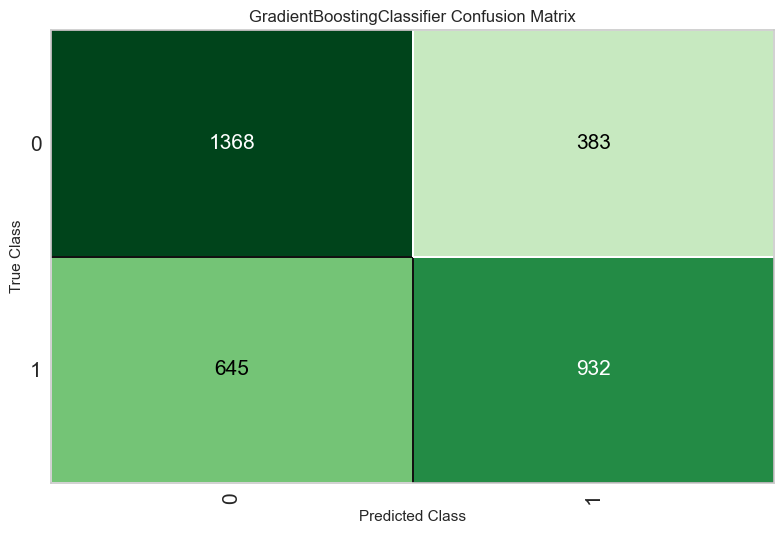

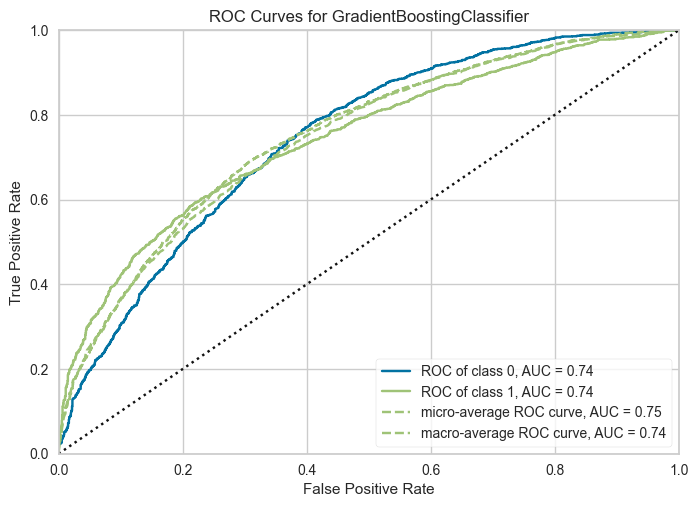

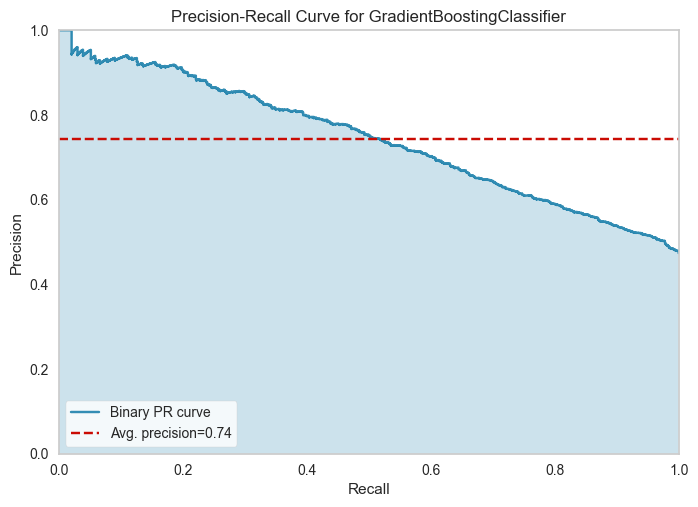

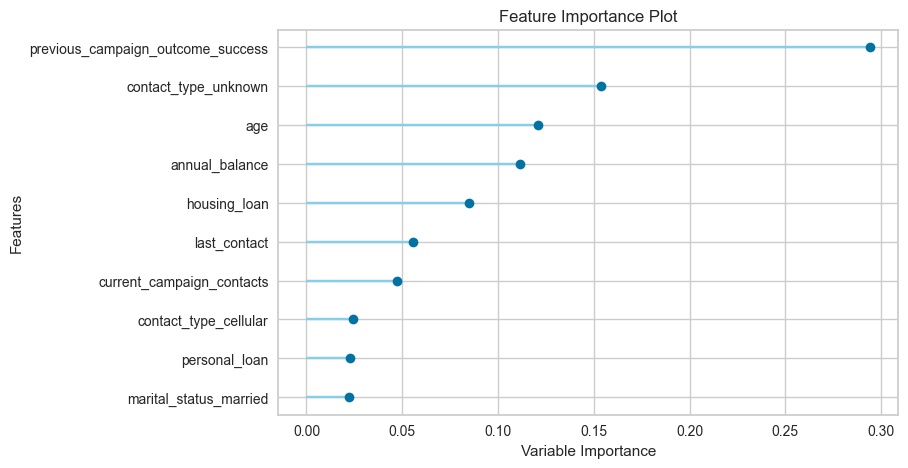

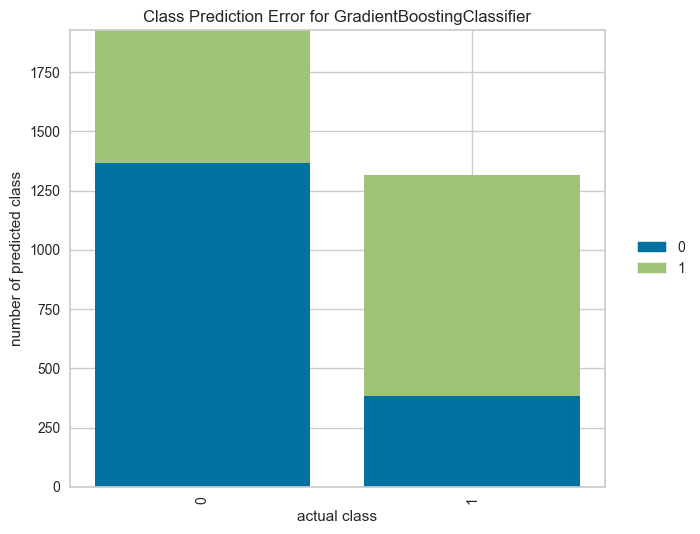

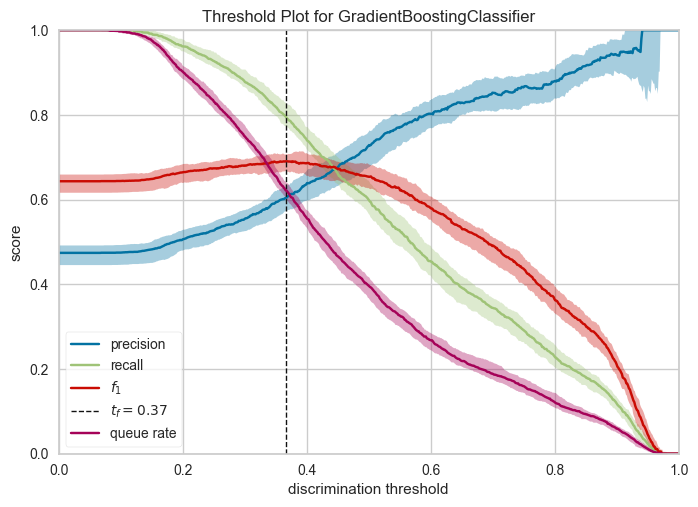

In [19]:
# Evaluation du meilleur Model

#  Visualisations manuelles des performances du modèle

# 1. Matrice de confusion
plot_model(best_model, plot='confusion_matrix')

# 2. Courbe ROC (Area Under Curve)
plot_model(best_model, plot='auc')

# 3. Courbe Précision-Rappel
plot_model(best_model, plot='pr')

# 4. Importance des variables
plot_model(best_model, plot='feature')

# 5. Erreurs de classification
plot_model(best_model, plot='error')

# 6. Seuil optimal de classification
plot_model(best_model, plot='threshold')



In [20]:

#  Sauvegarde du modèle
save_model(best_model, "best_model_pycaret")


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['age', 'annual_balance',
                                              'current_campaign_contacts',
                                              'last_contact',
                                              'previous_campaign_contact'],
                                     transformer=SimpleImputer(add_indicator=False...
                                             criterion='friedman_mse', init=None,
                                             learning_rate=0.1, loss='log_loss',
                                             max_depth=3, max_features=None,
                                             max_leaf_nodes=None,
    

In [23]:

#  Exemple de prédiction
predict_model(best_model)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.6911,0.7448,0.6911,0.6934,0.6879,0.3754,0.3802


,age,job,marital_status,education_level,credit_default,annual_balance,housing_loan,personal_loan,contact_type,current_campaign_contacts,last_contact,previous_campaign_contact,previous_campaign_outcome,contact_status,deposit,prediction_label,prediction_score
6209,49,management,divorced,tertiary,no,178,no,no,cellular,2,-1,0,unknown,no_contact,no,yes,0.5048
2497,29,admin.,single,tertiary,no,41,yes,no,cellular,2,-1,0,unknown,no_contact,yes,no,0.5336
255,37,blue-collar,married,unknown,no,1508,no,yes,unknown,2,-1,0,unknown,no_contact,yes,no,0.7826
9887,49,technician,divorced,secondary,no,342,no,yes,cellular,3,-1,0,unknown,no_contact,no,no,0.6108
402,43,blue-collar,single,primary,no,0,no,no,cellular,1,-1,0,unknown,no_contact,yes,no,0.5514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5369,57,management,divorced,unknown,no,0,no,no,unknown,1,-1,0,unknown,no_contact,no,no,0.7826
3326,35,admin.,married,secondary,no,304,no,no,cellular,1,-1,0,unknown,no_contact,yes,yes,0.5277
6315,40,blue-collar,divorced,secondary,no,793,yes,no,unknown,1,-1,0,unknown,no_contact,no,no,0.7628
7761,32,blue-collar,single,secondary,no,138,yes,no,cellular,2,-1,0,unknown,no_contact,no,no,0.5972
